In [3]:
import zipfile
import os

zip_path = "bank-additional.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("bank_data")

print("Files extracted:", os.listdir("bank_data"))

Files extracted: ['bank-additional', '__MACOSX']


In [6]:
import pandas as pd

df = pd.read_csv("bank-additional-full.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
total_contacts = len(df)
print("Total Contacts:", total_contacts)

Total Contacts: 41188


In [8]:
total_converted = df[df['y'] == 'yes'].shape[0]
print("Total Converted:", total_converted)

Total Converted: 4640


In [9]:
conversion_rate = (total_converted / total_contacts) * 100
print("Overall Conversion Rate: {:.2f}%".format(conversion_rate))

Overall Conversion Rate: 11.27%


In [10]:
drop_off = total_contacts - total_converted
print("Total Drop-offs:", drop_off)

Total Drop-offs: 36548


In [11]:
drop_percentage = (drop_off / total_contacts) * 100
print("Drop-off Rate: {:.2f}%".format(drop_percentage))

Drop-off Rate: 88.73%


In [12]:
channel_analysis = df.groupby('contact')['y'].value_counts(normalize=True).unstack() * 100
channel_analysis

y,no,yes
contact,,
cellular,85.262393,14.737607
telephone,94.768679,5.231321


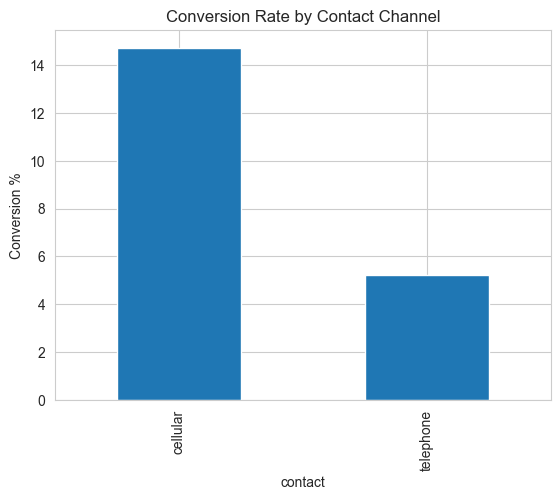

In [13]:
import matplotlib.pyplot as plt

channel_conversion = df.groupby('contact')['y'].apply(lambda x: (x=='yes').mean()*100)

channel_conversion.plot(kind='bar')
plt.title("Conversion Rate by Contact Channel")
plt.ylabel("Conversion %")
plt.show()

In [14]:
campaign_analysis = df.groupby('campaign')['y'].apply(lambda x: (x=='yes').mean()*100)
campaign_analysis.head(10)

campaign
1     13.037071
2     11.456954
3     10.747051
4      9.392682
5      7.504690
6      7.660878
7      6.041335
8      4.250000
9      6.007067
10     5.333333
Name: y, dtype: float64

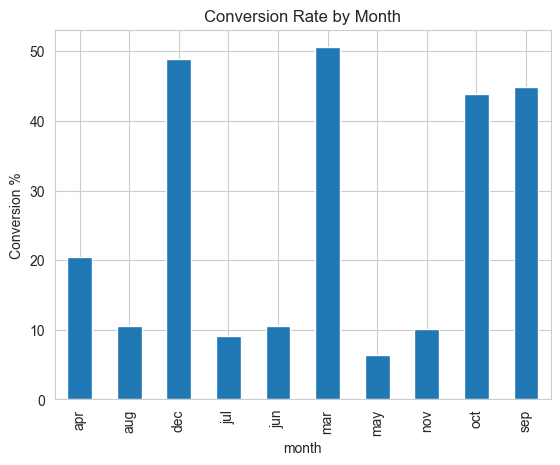

In [15]:
month_conversion = df.groupby('month')['y'].apply(lambda x: (x=='yes').mean()*100)

month_conversion.plot(kind='bar')
plt.title("Conversion Rate by Month")
plt.ylabel("Conversion %")
plt.show()

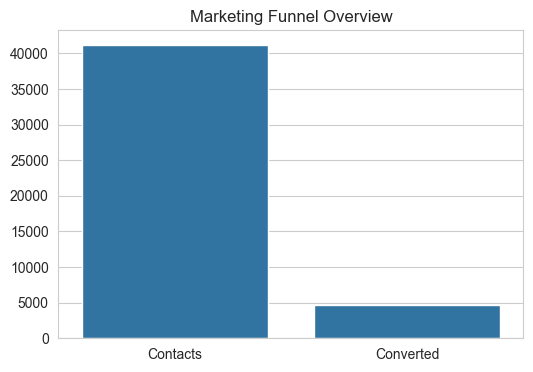

In [16]:
import seaborn as sns

funnel_data = [total_contacts, total_converted]
stages = ['Contacts', 'Converted']

plt.figure(figsize=(6,4))
sns.barplot(x=stages, y=funnel_data)
plt.title("Marketing Funnel Overview")
plt.show()

KeyError: 'Month'